# Phillies Modeling

## Read in data

In [21]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

import xgboost as xgb
import lightgbm as lgb

In [22]:
df = pd.read_csv("../data/phillies_square_modeling_df.csv", index_col=0)
df.drop(columns=['region', # captured by lat and lng
                 'OppScore', # captured by Team Score and Point diff
                 'Home', # all are home games
                 'Mets', # captured by opponent
                 'Braves', # captured by opponent
                 'StartTime', # Captured by start hour
                 "EndTime"] # Captured by end hour
        , inplace=True)

df

,date,hour,stop_count,Game,Day,LOG,DayGame,Rank,CLI,Attendance,...,Win,Walkoff,Season,Streak,Rivalry,start_hour,end_hour,game_period,lat,lng
858672,2014-03-31,0,0,1.0,Monday,216.0,1.0,1.0,0.96,49031.0,...,1.0,0.0,2014.0,1.0,0.0,14,18,before,4434,-6395
858673,2014-03-31,0,0,1.0,Monday,216.0,1.0,1.0,0.96,49031.0,...,1.0,0.0,2014.0,1.0,0.0,14,18,before,4434,-6394
858674,2014-03-31,0,0,1.0,Monday,216.0,1.0,1.0,0.96,49031.0,...,1.0,0.0,2014.0,1.0,0.0,14,18,before,4438,-6399
858675,2014-03-31,0,1,1.0,Monday,216.0,1.0,1.0,0.96,49031.0,...,1.0,0.0,2014.0,1.0,0.0,14,18,before,4435,-6398
858676,2014-03-31,0,1,1.0,Monday,216.0,1.0,1.0,0.96,49031.0,...,1.0,0.0,2014.0,1.0,0.0,14,18,before,4436,-6399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15166651,2018-04-14,23,0,13.0,Saturday,166.0,0.0,2.0,0.97,20934.0,...,1.0,0.0,2018.0,5.0,0.0,18,21,after,4427,-6392
15166652,2018-04-14,23,0,13.0,Saturday,166.0,0.0,2.0,0.97,20934.0,...,1.0,0.0,2018.0,5.0,0.0,18,21,after,4450,-6397
15166653,2018-04-14,23,0,13.0,Saturday,166.0,0.0,2.0,0.97,20934.0,...,1.0,0.0,2018.0,5.0,0.0,18,21,after,4449,-6396
15166654,2018-04-14,23,0,13.0,Saturday,166.0,0.0,2.0,0.97,20934.0,...,1.0,0.0,2018.0,5.0,0.0,18,21,after,4446,-6401


In [23]:
df.columns

Index(['date', 'hour', 'stop_count', 'Game', 'Day', 'LOG', 'DayGame', 'Rank',
       'CLI', 'Attendance', 'Opp', 'TeamScore', 'PointDiff', 'Win', 'Walkoff',
       'Season', 'Streak', 'Rivalry', 'start_hour', 'end_hour', 'game_period',
       'lat', 'lng'],
      dtype='object')

## Define features and one-hot encode categorical variables

In [24]:
features = ['hour',  'Game', 'Day', 'LOG', 'DayGame', 'Rank',
       'CLI', 'Attendance', 'Opp', 'TeamScore', 'PointDiff', 'Win', 'Walkoff',
       'Season', 'Streak', 'Rivalry', 'start_hour', 'end_hour', 'game_period',
       'lat', 'lng']

X = df[features].copy()
y = df['stop_count']

# Convert categorical text/objects into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Day', 'Opp',  'Season', 'game_period'],
                   drop_first=True,
                   dtype=int)

X

,hour,Game,LOG,DayGame,Rank,CLI,Attendance,TeamScore,PointDiff,Win,...,Opp_TBR,Opp_TEX,Opp_TOR,Opp_WSN,Season_2015.0,Season_2016.0,Season_2017.0,Season_2018.0,game_period_before,game_period_during
858672,0,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
858673,0,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
858674,0,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
858675,0,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
858676,0,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15166651,23,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,0
15166652,23,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,0
15166653,23,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,0
15166654,23,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,0


## Split data into training, validation, testing (grouped on date, hour)

In [25]:
from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each date + hour
df['group_id'] = df['date'].astype(str) + "_" + df['hour'].astype(str)

# Use GroupShuffleSplit instead of regular train_test_split

#  Split out test set (20%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, y, groups=df['group_id']))

X_train_val = X.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = df['group_id'].iloc[train_val_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Split train_val into train (70) and validation (10)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups=groups_train_val))

X_train = X_train_val.iloc[train_idx]
y_train = y_train_val.iloc[train_idx]

X_val = X_train_val.iloc[val_idx]
y_val = y_train_val.iloc[val_idx]


In [26]:
print(len(X_val), len(X_test), len(X_train))

318786 638376 2236326


In [27]:
X_val

,hour,Game,LOG,DayGame,Rank,CLI,Attendance,TeamScore,PointDiff,Win,...,Opp_TBR,Opp_TEX,Opp_TOR,Opp_WSN,Season_2015.0,Season_2016.0,Season_2017.0,Season_2018.0,game_period_before,game_period_during
860280,4,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
860281,4,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
860282,4,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
860283,4,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
860284,4,1.0,216.0,1.0,1.0,0.96,49031.0,14.0,4.0,1.0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15165043,19,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,1
15165044,19,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,1
15165045,19,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,1
15165046,19,13.0,166.0,0.0,2.0,0.97,20934.0,9.0,5.0,1.0,...,1,0,0,0,0,0,0,1,0,1


In [28]:
y_val

860280      0
860281      0
860282      0
860283      0
860284      0
           ..
15165043    0
15165044    0
15165045    0
15165046    0
15165047    0
Name: stop_count, Length: 318786, dtype: int64

## Fit Different Models on Validation Set

### Define Evaluation Function

In [29]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    preds_int = np.rint(preds).astype(int)
    mae = mean_absolute_error(y, preds_int)
    rmse = np.sqrt(mean_squared_error(y, preds_int))
    return mae, rmse


### Define Feature Sets

In [30]:
feature_sets = {
    "all_features": X_val.columns.tolist(),
   # "top_features": ["lng", "lat", "hour"]
}


### Define Hyperparameter Grids

In [31]:
xgb_params = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

rf_params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
}

lgb_params = {
    "n_estimators": [100, 300],
    "num_leaves": [31, 50],
    "learning_rate": [0.05, 0.1],
}

### Try the different models

In [32]:
results = []

for feature_set_name, features in feature_sets.items():

    X_tr = X_train[features]
    X_v = X_val[features]

    # -------------------
    # XGBOOST
    # -------------------
    for params in ParameterGrid(xgb_params):
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            **params
        )

        model.fit(X_tr, y_train)
        mae, rmse = evaluate_model(model, X_v, y_val)

        results.append({
            "model": "XGBoost",
            "feature_set": feature_set_name,
            "params": params,
            "val_mae": mae,
            "val_rmse": rmse
        })

    print(results)

    # # -------------------
    # # RANDOM FOREST
    # # -------------------
    # for params in ParameterGrid(rf_params):
    #     model = RandomForestRegressor(
    #         random_state=42,
    #         n_jobs=-1,
    #         **params
    #     )
    #
    #     model.fit(X_tr, y_train)
    #     mae, rmse = evaluate_model(model, X_v, y_val)
    #
    #     results.append({
    #         "model": "RandomForest",
    #         "feature_set": feature_set_name,
    #         "params": params,
    #         "val_mae": mae,
    #         "val_rmse": rmse
    #     })
    # print(results)
    # -------------------
    # LIGHTGBM
    # -------------------
    for params in ParameterGrid(lgb_params):
        model = lgb.LGBMRegressor(
            random_state=42,
            **params
        )

        model.fit(X_tr, y_train)
        mae, rmse = evaluate_model(model, X_v, y_val)

        results.append({
            "model": "LightGBM",
            "feature_set": feature_set_name,
            "params": params,
            "val_mae": mae,
            "val_rmse": rmse
        })
    print(results)

[{'model': 'XGBoost', 'feature_set': 'all_features', 'params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}, 'val_mae': 0.11847132559146262, 'val_rmse': np.float64(0.5396484434832913)}, {'model': 'XGBoost', 'feature_set': 'all_features', 'params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}, 'val_mae': 0.11849955769701305, 'val_rmse': np.float64(0.5396339111387047)}, {'model': 'XGBoost', 'feature_set': 'all_features', 'params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}, 'val_mae': 0.12484237074401008, 'val_rmse': np.float64(0.5225102948987166)}, {'model': 'XGBoost', 'feature_set': 'all_features', 'params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}, 'val_mae': 0.12463847220392364, 'val_rmse': np.float64(0.5224112274394496)}, {'model': 'XGBoost', 'feature_set': 'all_features', 'params': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 

### Compare Results

In [33]:
results_df = pd.DataFrame(results)

# Sort by validation MAE (or RMSE)
results_df = results_df.sort_values(by="val_rmse")

results_df


,model,feature_set,params,val_mae,val_rmse
23,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.118267,0.474663
22,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.119027,0.479050
19,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 300, '...",0.118766,0.479145
21,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.118738,0.482541
18,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 300, '...",0.118879,0.483246
20,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.119284,0.486523
17,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.119124,0.488206
14,XGBoost,all_features,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.122593,0.489784
15,XGBoost,all_features,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.122273,0.489797
16,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.119688,0.493179


### Select Best Model

In [34]:
best_row = results_df.iloc[0]

best_model_name = best_row["model"]
best_params = best_row["params"]
best_features = feature_sets[best_row["feature_set"]]

print(best_row)


model                                                   LightGBM
feature_set                                         all_features
params         {'learning_rate': 0.1, 'n_estimators': 300, 'n...
val_mae                                                 0.118267
val_rmse                                                0.474663
Name: 23, dtype: object


## SHAP (using validation set to go backwards and influence variable sets)

/Users/vijetharamdas/Documents/PhillyProject/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


      model   feature_set                                             params  \
0  LightGBM  all_features  {'learning_rate': 0.1, 'n_estimators': 300, 'n...   
1  LightGBM  all_features  {'learning_rate': 0.1, 'n_estimators': 300, 'n...   
2  LightGBM  all_features  {'learning_rate': 0.05, 'n_estimators': 300, '...   

    val_mae  val_rmse  
0  0.118267  0.474663  
1  0.119027  0.479050  
2  0.118766  0.479145  

Running SHAP for model 1: LightGBM (all_features)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 2236326, number of used features: 54
[LightGBM] [Info] Start training from score 0.117447


 94%|=================== | 4711/5000 [00:16<00:00]       

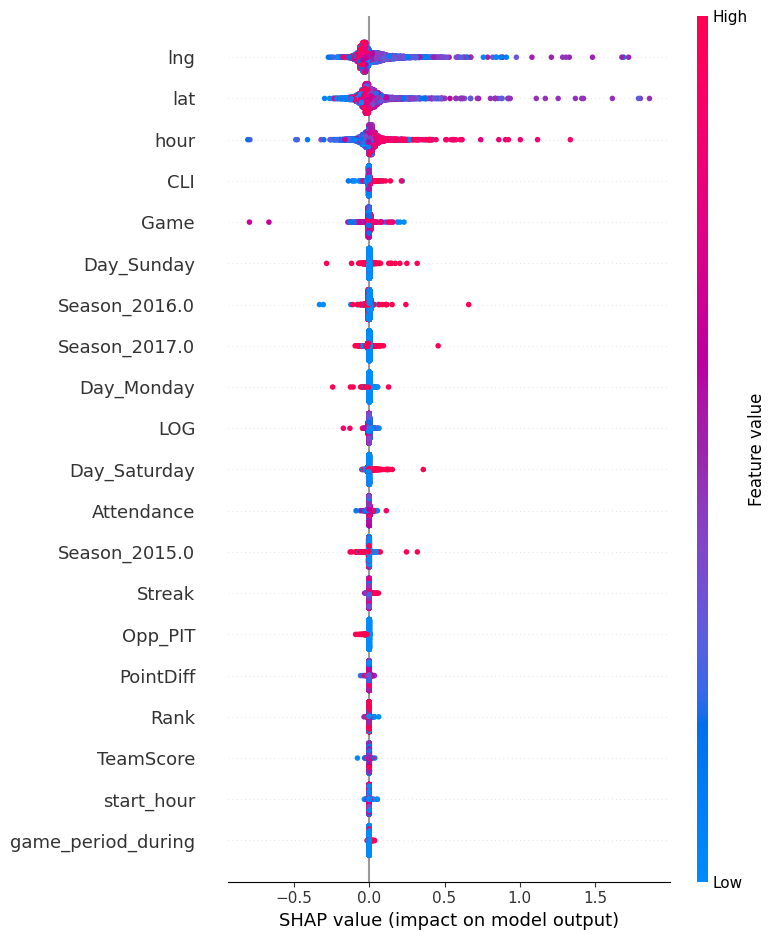

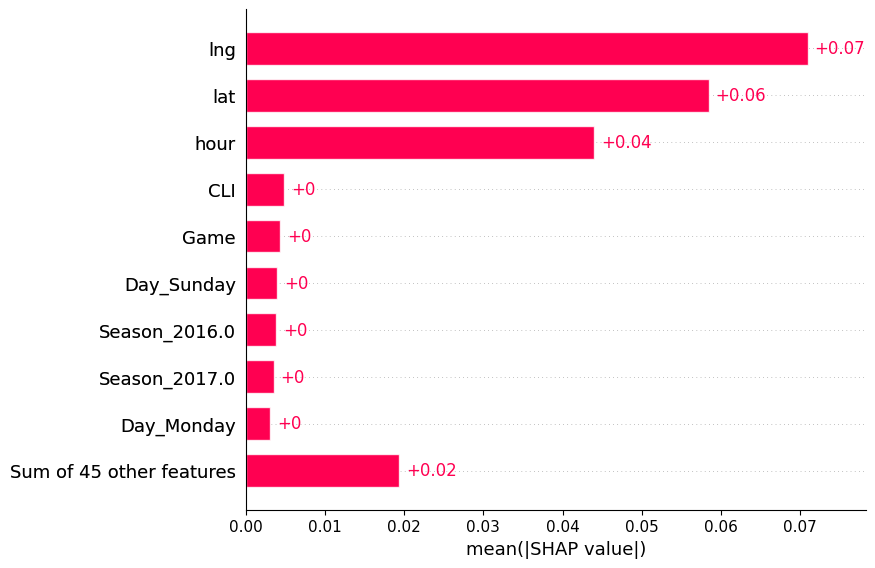


Running SHAP for model 2: LightGBM (all_features)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 2236326, number of used features: 54
[LightGBM] [Info] Start training from score 0.117447


 94%|=================== | 4691/5000 [00:13<00:00]       

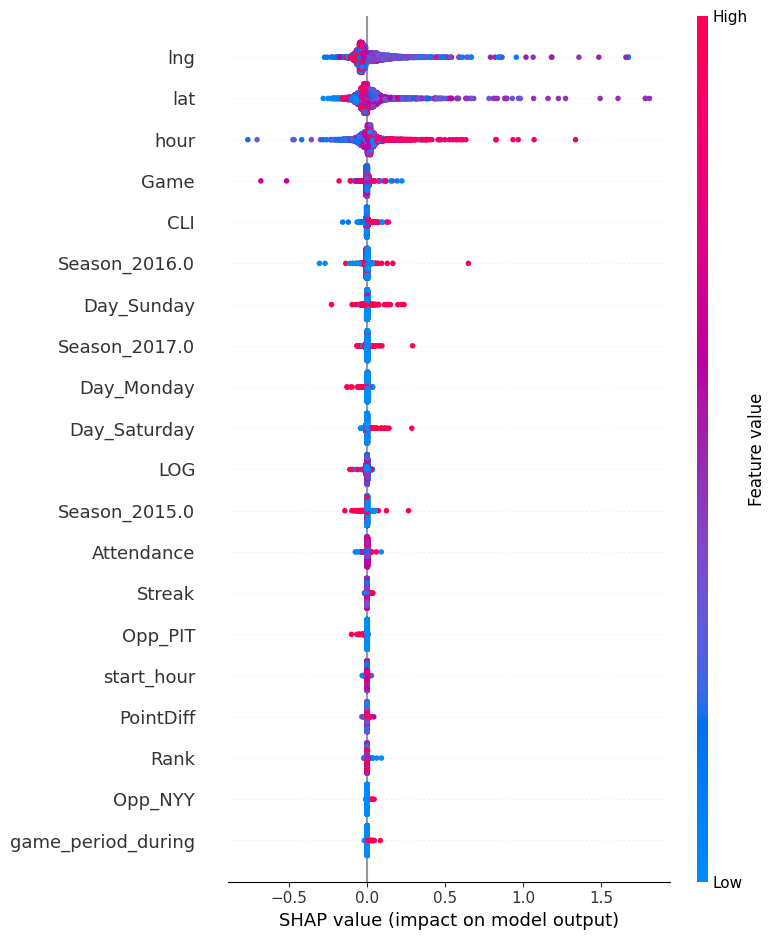

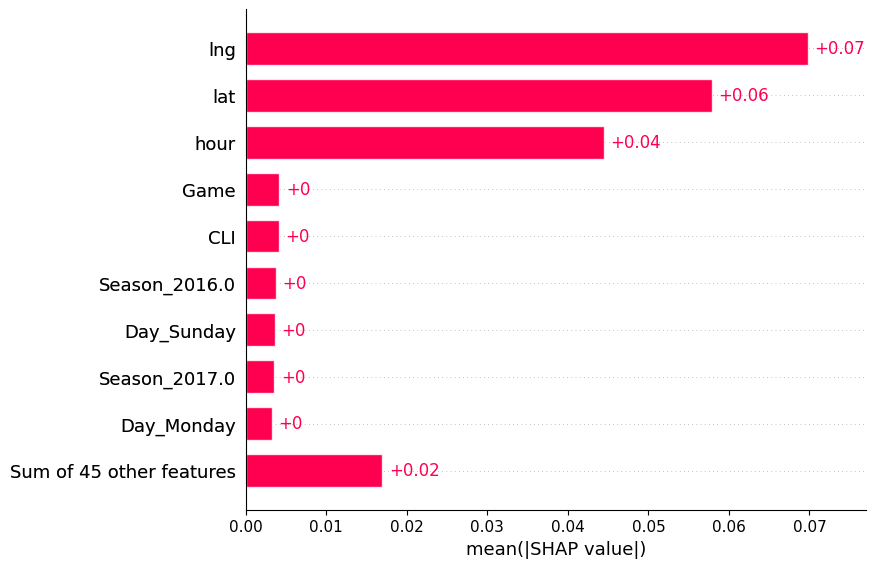


Running SHAP for model 3: LightGBM (all_features)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 2236326, number of used features: 54
[LightGBM] [Info] Start training from score 0.117447


 96%|=================== | 4784/5000 [00:20<00:00]       

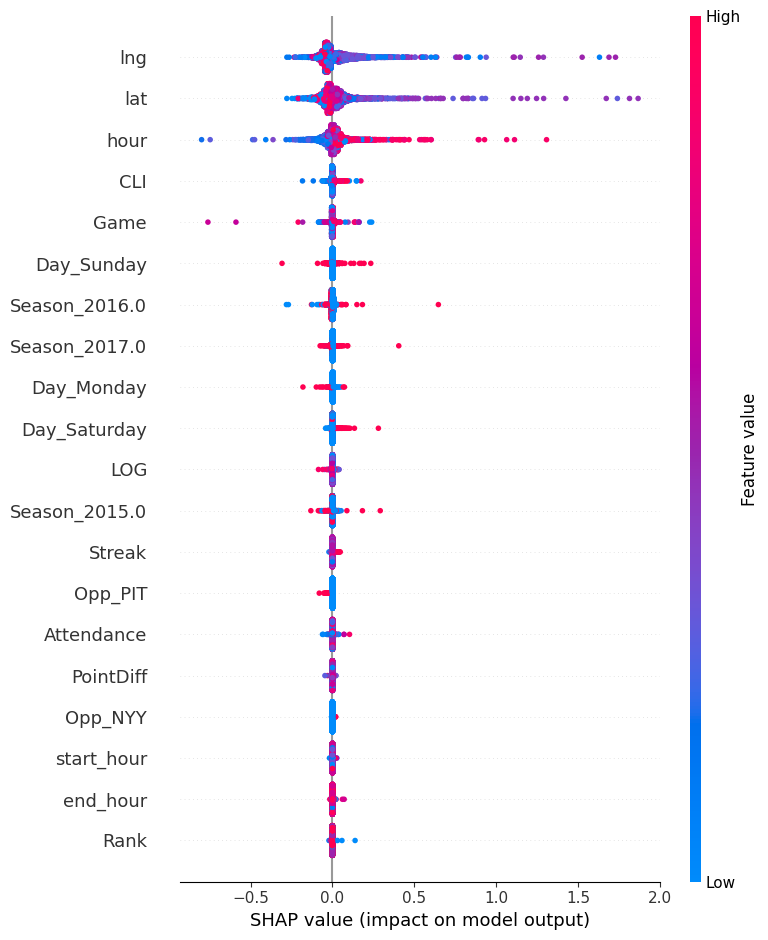

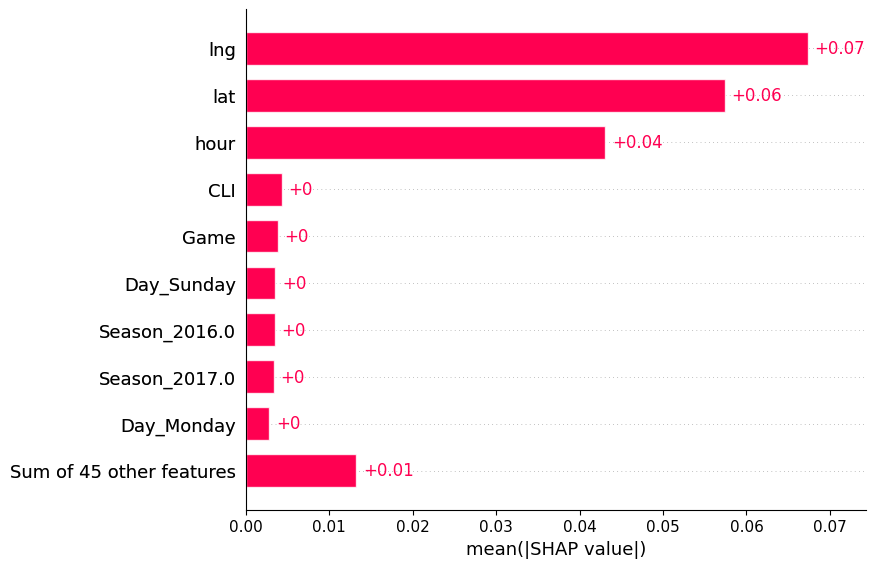

In [35]:
import shap

# Ensure sorted (just in case)
results_df = results_df.sort_values(by="val_rmse").reset_index(drop=True)

top_3 = results_df.head(3)
print(top_3)

def build_model(model_name, params):
    if model_name == "XGBoost":
        return xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            **params
        )

    elif model_name == "RandomForest":
        return RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )

    elif model_name == "LightGBM":
        return lgb.LGBMRegressor(
            random_state=42,
            **params
        )

shap_results = []

for i, row in top_3.iterrows():

    model_name = row["model"]
    params = row["params"]
    feature_set_name = row["feature_set"]
    features = feature_sets[feature_set_name]

    print(f"\nRunning SHAP for model {i+1}: {model_name} ({feature_set_name})")

    # Prepare data
    X_tr = X_train[features]
    X_v = X_val[features]

    # Build + fit model
    model = build_model(model_name, params)
    model.fit(X_tr, y_train)

    # Sample validation set (for speed)
    X_sample = X_v.sample(n=min(5000, len(X_v)), random_state=42)

    # SHAP
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)

    # Store results
    shap_results.append({
        "model": model_name,
        "feature_set": feature_set_name,
        "explainer": explainer,
        "shap_values": shap_values,
        "X_sample": X_sample
    })

    # Plot summary
    shap.summary_plot(shap_values, X_sample)

    # Plot bar (clean importance)
    shap.plots.bar(shap_values)



+## Fit selected model using training data

In [36]:
X_tr_final = X_train[best_features]
X_test_final = X_test[best_features]

if best_model_name == "XGBoost":
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params
    )

elif best_model_name == "RandomForest":
    final_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_params
    )

elif best_model_name == "LightGBM":
    final_model = lgb.LGBMRegressor(
        random_state=42,
        **best_params
    )

final_model.fit(X_tr_final, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 2236326, number of used features: 54
[LightGBM] [Info] Start training from score 0.117447


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Final Evaluation on Test Data

In [37]:
test_mae, test_rmse = evaluate_model(final_model, X_test_final, y_test)

print(f"Final Test MAE: {test_mae:.4f}")
print(f"Final Test RMSE: {test_rmse:.4f}")

Final Test MAE: 0.1166
Final Test RMSE: 0.4692


## Create baseline Model for Comparison

In [38]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

# Round predictions to nearest integer
y_pred_int = np.rint(y_pred).astype(int)

# Evaluate
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_int))
base_mae = mean_absolute_error(y_test, y_pred_int)

print(f"Baseline MAE: {base_mae:.4f}")
print(f"Baseline RMSE: {base_rmse:.4f}")


Baseline MAE: 0.1172
Baseline RMSE: 0.5471


## SHAP on final model

 95%|=================== | 4766/5000 [00:16<00:00]       

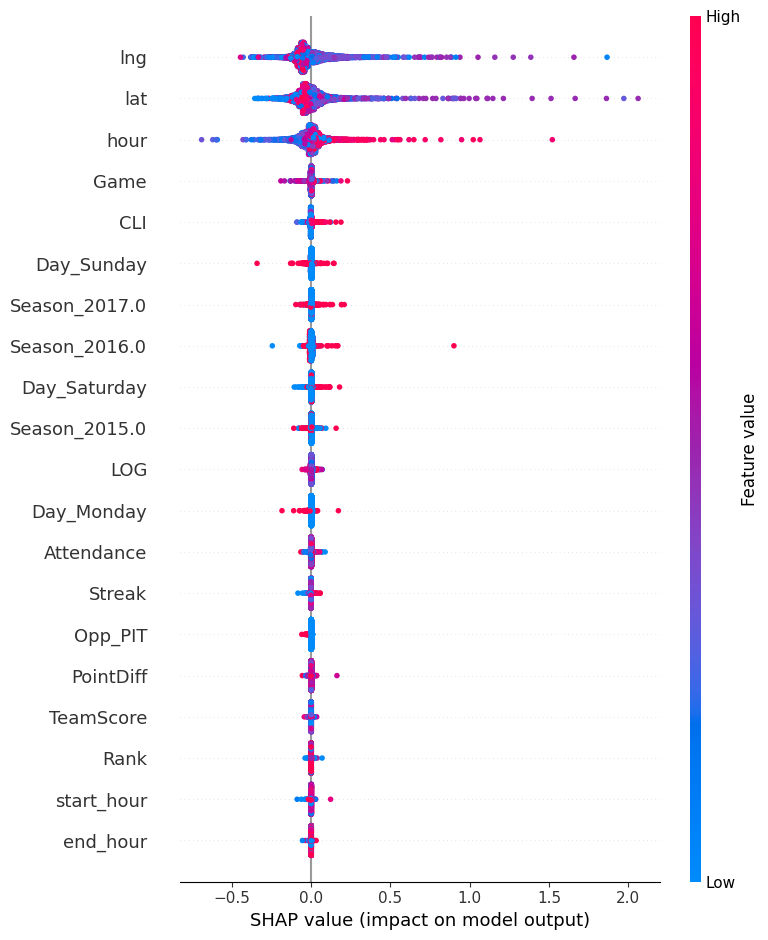

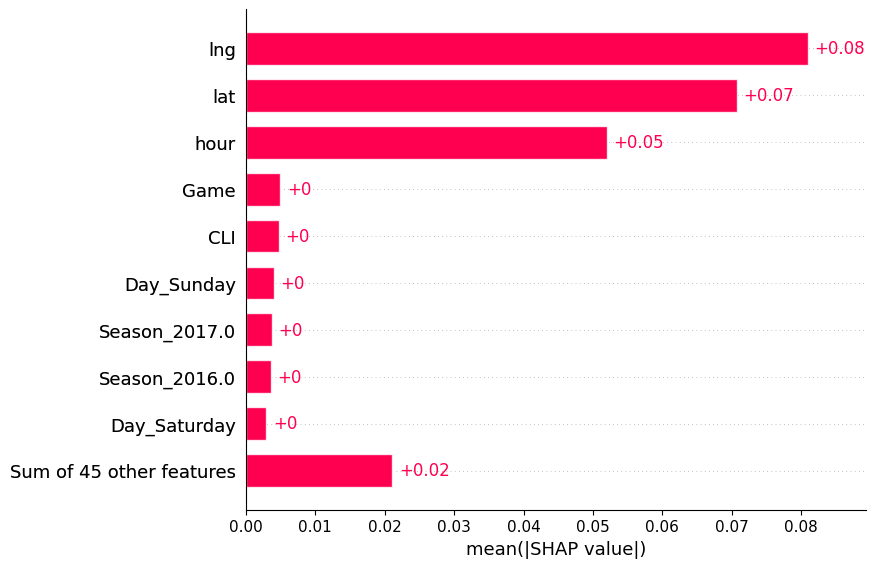

In [39]:
X_shap = X_test_final.sample(
    n=min(5000, len(X_test_final)),
    random_state=42
)

explainer = shap.Explainer(final_model, X_shap)
shap_values = explainer(X_shap)

shap.summary_plot(shap_values, X_shap)

shap.plots.bar(shap_values)
